# Load and Inspect Combined Forecast Dataset (ICON-D2 + GEFS)

This notebook demonstrates how to load and inspect the CombinedForecastDataset which merges:
- **ICON-D2**: Short-range 48h forecasts (high resolution, local NetCDF)
- **GEFS**: Extended 10-day forecasts (NOAA Zarr store)

Key features:
- ICON-D2 variables are suffixed with `_icond2`
- ICON-D2 data is zero-padded for lead times beyond 48h
- `icond2_available` mask indicates where ICON-D2 data is valid (1 for h1-48, 0 for h49-240)

In [1]:
import sys
import torch
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from datetime import timedelta
from pathlib import Path
from matplotlib import dates as mdates

from neuralhydrology.utils.config import Config
from neuralhydrology.datasetzoo.onlineforecast_combined_dataset import CombinedForecastDataset

## Load Configuration

Load the configuration file that specifies both ICON-D2 and GEFS variables.

In [2]:
# Load the config file
config_path = Path("config_icond2_gefs.yml")
config = Config(config_path)

## Create Combined Forecast Dataset

Initialize the CombinedForecastDataset which will:
1. Load ICON-D2 data from local NetCDF files
2. Load GEFS data from NOAA Zarr store
3. Merge them with zero-padding for ICON-D2 beyond 48h

In [3]:
# Initialize the dataset
# Explicitly pass scaler={} to ensure a fresh empty dict is used 
# (avoids Python mutable default argument issue)
dataset = CombinedForecastDataset(cfg=config, is_train=True, period='train', scaler={})

100%|██████████| 2/2 [01:03<00:00, 31.71s/it]


## Inspect the Merged XArray Dataset

Examine the structure of the combined dataset showing both ICON-D2 and GEFS variables.

In [4]:
# Access the internal xarray dataset
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    xr_dataset = dataset._load_or_create_xarray_dataset()

    print("=== XArray Dataset Structure ===")
    print(xr_dataset)

    print("\n=== Variables by Source ===")
    icond2_vars = [v for v in xr_dataset.data_vars if '_icond2' in v]
    gefs_vars = [v for v in xr_dataset.data_vars if '_icond2' not in v and v != 'icond2_available']
    print(f"ICON-D2 variables: {icond2_vars}")
    print(f"GEFS variables: {gefs_vars}")
    print(f"Mask: {'icond2_available' in xr_dataset.data_vars}")

=== XArray Dataset Structure ===
<xarray.Dataset> Size: 97MB
Dimensions:                          (basin: 2, gauge_id: 1, issue_time: 1175,
                                      lead_time: 240, time: 29400)
Coordinates:
  * lead_time                        (lead_time) timedelta64[ns] 2kB 01:00:00...
    latitude                         float64 8B 51.75
    expected_forecast_length         (basin, issue_time) timedelta64[ns] 19kB ...
  * basin                            (basin) object 16B 'DE2' 'DE4'
  * issue_time                       (issue_time) datetime64[ns] 9kB 2021-02-...
    spatial_ref                      int64 8B 0
    longitude                        float64 8B 10.5
  * time                             (time) datetime64[ns] 235kB 2020-12-23 ....
Dimensions without coordinates: gauge_id
Data variables: (12/35)
    precipitation_mean_icond2_q50    (basin, gauge_id, issue_time, lead_time) float64 5MB dask.array<chunksize=(1, 1, 294, 120), meta=np.ndarray>
    shortwave_radiati

## Plot Forecast Comparison: ICON-D2 vs GEFS

Visualize the 24.12.2023 00Z forecast showing:
- Historical observations (past 7 days)
- ICON-D2 forecast (0-48h, high resolution)
- GEFS forecast (0-240h, extended range)
- The `icond2_available` mask

In [5]:
# Select basin and target issue time
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    basin_id = 'DE2'  # Ecker catchment
    target_issue_time = pd.Timestamp('2023-12-24 00:00:00')

    # Select data for this basin
    ds = xr_dataset.sel(basin=basin_id)

    # Check if target issue time exists
    available_issues = pd.to_datetime(ds['issue_time'].values)
    if target_issue_time not in available_issues:
        print(f"Warning: {target_issue_time} not found. Using nearest available.")
        idx = available_issues.get_indexer([target_issue_time], method='nearest')[0]
        target_issue_time = available_issues[idx]
        print(f"Using: {target_issue_time}")

    print(f"Plotting forecast for basin {basin_id} at {target_issue_time}")

Plotting forecast for basin DE2 at 2023-12-24 00:00:00


In [6]:
# Extract forecast data
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    fcst = ds.sel(issue_time=target_issue_time)
    lead_times = fcst['lead_time'].values  # Hours (integer)
    forecast_dates = target_issue_time + pd.to_timedelta(lead_times, unit='h')

    # Extract historical data (7 days before forecast)
    hist_end = target_issue_time
    hist_start = hist_end - pd.Timedelta(days=7)
    
    # Check if 'time' dimension exists and has data in this range
    if 'time' in ds.dims:
        hist = ds.sel(time=slice(hist_start, hist_end))
        hist_dates = pd.to_datetime(hist['time'].values)
        print(f"Historical period: {hist_start} to {hist_end} ({len(hist_dates)} timesteps)")
    else:
        hist = None
        hist_dates = []
        print("No historical time dimension found.")
    
    print(f"Forecast period: {forecast_dates[0]} to {forecast_dates[-1]}")
    print(f"Lead times: {lead_times[0]}h to {lead_times[-1]}h ({len(lead_times)} steps)")

Historical period: 2023-12-17 00:00:00 to 2023-12-24 00:00:00 (169 timesteps)
Forecast period: 2023-12-24 01:00:00 to 2024-01-03 00:00:00
Lead times: 3600000000000 nanosecondsh to 864000000000000 nanosecondsh (240 steps)


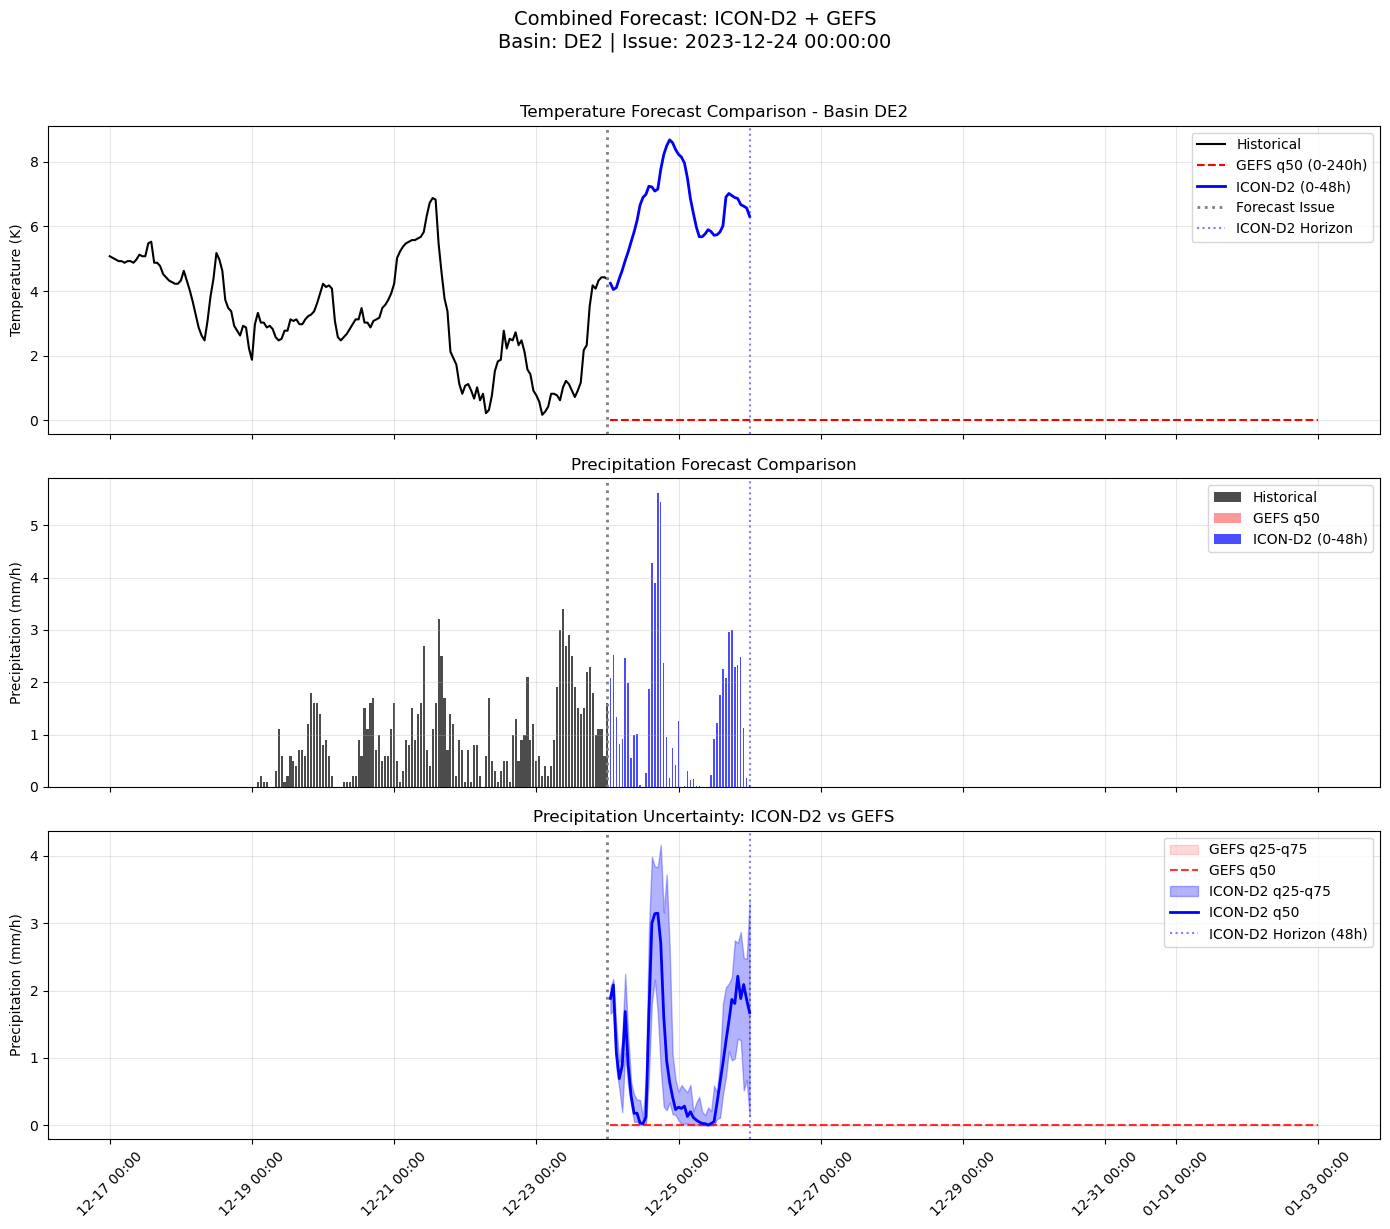

In [ ]:
# Create comparison plot
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # Helper function to flatten data arrays (squeeze extra dimensions)
    def flatten(arr):
        return np.array(arr).flatten()

    # Constants mapping config names to plot logic
    TEMP_VAR_GEFS = 'temperature_2m_gefs_q50'
    PRECIP_VAR_GEFS = 'precipitation_surface_gefs_q50'
    PRECIP_VAR_GEFS_Q25 = 'precipitation_surface_gefs_q25'
    PRECIP_VAR_GEFS_Q75 = 'precipitation_surface_gefs_q75'

    # --- 1. Temperature ---
    ax = axes[0]
    # Historical
    if hist is not None and 'temperature_2m' in hist.data_vars and len(hist_dates) > 0:
        ax.plot(hist_dates, flatten(hist['temperature_2m'].values), 'k-', lw=1.5, label='Historical')

    # GEFS (Convert Kelvin to Celsius)
    if TEMP_VAR_GEFS in fcst.data_vars:
        gefs_temp = flatten(fcst[TEMP_VAR_GEFS].values)
        # Check if approx Kelvin range (> 200)
        if np.mean(gefs_temp) > 200:
            gefs_temp = gefs_temp - 273.15
            print("Converted GEFS Temperature from Kelvin to Celsius")
        ax.plot(forecast_dates, gefs_temp, 'r--', lw=1.5, label='GEFS q50 (0-240h)')

    # ICON-D2 (only valid for first 48h)
    if 'temperature_mean_icond2' in fcst.data_vars:
        icond2_temp = flatten(fcst['temperature_mean_icond2'].values)
        if 'icond2_available' in fcst.data_vars:
            mask = flatten(fcst['icond2_available'].values) == 1
        else:
            mask = lead_times <= 48
         # Check if ICON-D2 is Kelvin (unlikely for DWD but possible)
        if np.mean(icond2_temp[mask]) > 200:
             icond2_temp = icond2_temp - 273.15
             print("Converted ICON-D2 Temperature from Kelvin to Celsius")

        ax.plot(forecast_dates[mask], icond2_temp[mask], 'b-', lw=2, label='ICON-D2 (0-48h)')

    ax.axvline(target_issue_time, color='gray', linestyle=':', lw=2, label='Forecast Issue')
    ax.axvline(target_issue_time + pd.Timedelta(hours=48), color='blue', linestyle=':', alpha=0.5, label='ICON-D2 Horizon')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Temperature Forecast Comparison - Basin {basin_id}')

    # --- 2. Precipitation ---
    ax = axes[1]
    # Historical
    if hist is not None and 'precipitation' in hist.data_vars and len(hist_dates) > 0:
        ax.bar(hist_dates, flatten(hist['precipitation'].values), width=0.03, color='black', alpha=0.7, label='Historical')

    # GEFS precipitation (Convert mm/s to mm/h)
    if PRECIP_VAR_GEFS in fcst.data_vars:
        gefs_q50 = flatten(fcst[PRECIP_VAR_GEFS].values) * 3600
        ax.bar(forecast_dates, gefs_q50, width=0.03, color='red', alpha=0.4, label='GEFS q50')
        
    # ICON-D2 precipitation
    if 'precipitation_mean_icond2' in fcst.data_vars:
        icond2_prec = flatten(fcst['precipitation_mean_icond2'].values)
        if 'icond2_available' in fcst.data_vars:
            mask = flatten(fcst['icond2_available'].values) == 1
        else:
            mask = lead_times <= 48
        # Plot ICON-D2 slightly offset or on top
        ax.bar(forecast_dates[mask], icond2_prec[mask], width=0.02, color='blue', alpha=0.7, label='ICON-D2 (0-48h)')

    ax.axvline(target_issue_time, color='gray', linestyle=':', lw=2)
    ax.axvline(target_issue_time + pd.Timedelta(hours=48), color='blue', linestyle=':', alpha=0.5)
    ax.set_ylabel('Precipitation (mm/h)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_title('Precipitation Forecast Comparison')

    # --- 3. Uncertainty Comparison (Precipitation) ---
    ax = axes[2]
    
    # GEFS Uncertainty (Convert mm/s to mm/h)
    if PRECIP_VAR_GEFS in fcst.data_vars and \
       PRECIP_VAR_GEFS_Q25 in fcst.data_vars and \
       PRECIP_VAR_GEFS_Q75 in fcst.data_vars:
        
        gefs_q25 = flatten(fcst[PRECIP_VAR_GEFS_Q25].values) * 3600
        gefs_q50 = flatten(fcst[PRECIP_VAR_GEFS].values) * 3600
        gefs_q75 = flatten(fcst[PRECIP_VAR_GEFS_Q75].values) * 3600
        
        ax.fill_between(forecast_dates, gefs_q25, gefs_q75, color='red', alpha=0.15, label='GEFS q25-q75')
        ax.plot(forecast_dates, gefs_q50, 'r--', lw=1.5, alpha=0.8, label='GEFS q50')

    # ICON-D2 Uncertainty
    quartile_vars = ['precipitation_mean_icond2_q25', 'precipitation_mean_icond2_q50', 'precipitation_mean_icond2_q75']
    if all(v in fcst.data_vars for v in quartile_vars):
        q25 = flatten(fcst['precipitation_mean_icond2_q25'].values)
        q50 = flatten(fcst['precipitation_mean_icond2_q50'].values)
        q75 = flatten(fcst['precipitation_mean_icond2_q75'].values)
        
        if 'icond2_available' in fcst.data_vars:
            mask = flatten(fcst['icond2_available'].values) == 1
        else:
            mask = lead_times <= 48
        
        ax.fill_between(forecast_dates[mask], q25[mask], q75[mask], color='blue', alpha=0.3, label='ICON-D2 q25-q75')
        ax.plot(forecast_dates[mask], q50[mask], 'b-', lw=2, label='ICON-D2 q50')
    
    ax.axvline(target_issue_time, color='gray', linestyle=':', lw=2)
    ax.axvline(target_issue_time + pd.Timedelta(hours=48), color='blue', linestyle=':', alpha=0.5, label='ICON-D2 Horizon (48h)')
    ax.set_ylabel('Precipitation (mm/h)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_title('Precipitation Uncertainty: ICON-D2 vs GEFS')

    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45)

    plt.suptitle(f'Combined Forecast: ICON-D2 + GEFS\nBasin: {basin_id} | Issue: {target_issue_time}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Inspect a Single Sample

Let's look at what a single training sample looks like from the dataset.

In [ ]:
# Get a sample from the dataset
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
else:
    sample_idx = 0
    sample = dataset[sample_idx]

    print("=== Sample Structure ===")
    for key, value in sample.items():
        if isinstance(value, torch.Tensor):
            print(f"{key}: shape={value.shape}, dtype={value.dtype}")
        elif isinstance(value, dict):
            print(f"{key}: dict with {len(value)} keys")
        else:
            print(f"{key}: {type(value).__name__}")

In [ ]:
# Examine forecast inputs tensor
if dataset is None:
    print("Dataset not initialized. Skipping this cell.")
elif 'x_f' in sample:
    x_f = sample['x_f']
    print(f"Forecast tensor shape: {x_f.shape}")
    print(f"  - Dimension 0 (lead_time): {x_f.shape[0]} hours")
    print(f"  - Dimension 1 (features): {x_f.shape[1]} variables")
    print(f"\nForecast variables: {config.forecast_inputs}")
    
    # Check for NaN or zeros in ICON-D2 region vs padded region
    if 'icond2_available' in config.forecast_inputs:
        icond2_idx = config.forecast_inputs.index('icond2_available')
        mask = x_f[:, icond2_idx]
        valid_count = int((mask == 1).sum())
        total_count = len(mask)
        print(f"\nICON-D2 availability mask:")
        print(f"  - Valid (=1) for hours 1-{valid_count}")
        print(f"  - Padded (=0) for hours {valid_count+1}-{total_count}")
    else:
        print("\nicond2_available not in forecast_inputs")
else:
    print("No 'x_f' tensor in sample.")

## Summary

The `CombinedForecastDataset` successfully merges:

1. **ICON-D2** (48h horizon):
   - High-resolution deterministic: `precipitation_mean_icond2`, `temperature_mean_icond2`
   - Ensemble quartiles: `precipitation_mean_icond2_q25/q50/q75`
   - Zero-padded beyond 48h

2. **GEFS** (240h horizon):
   - Extended range quartiles: `precipitation_amount_q25/q50/q75`, `temperature_2m_q50`
   - Full 10-day coverage

3. **Availability Mask**:
   - `icond2_available`: Binary indicator (1=valid ICON-D2, 0=padded)
   - Allows model to learn when to trust ICON-D2 vs fallback to GEFS